In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv ("C:/Users/sinch/Downloads/BlinkIT_sales.csv"  , encoding = "ISO-8859-1")
data

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.100,145.4786,5
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.800,115.3492,5
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.850,165.0210,5
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.150,126.5046,5
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.600,55.1614,5
...,...,...,...,...,...,...,...,...,...,...,...,...
245,reg,FDW31,Fruits and Vegetables,2020,OUT017,Tier 2,Medium,Supermarket Type1,0.043402,11.350,197.0742,5
246,reg,FDR55,Fruits and Vegetables,2020,OUT017,Tier 2,Medium,Supermarket Type1,0.132831,12.150,190.6872,5
247,reg,FDX10,Snack Foods,2020,OUT017,Tier 2,Medium,Supermarket Type1,0.124410,6.385,34.3874,5
248,LF,DRF49,Soft Drinks,2017,OUT035,Tier 2,Small,Supermarket Type1,0.071064,7.270,114.4518,5


# Find which product categories perform better

In [5]:
avg_sales_item = data.groupby('Item Type')['Sales'].mean().sort_values(ascending=False)
avg_sales_item

Item Type
Starchy Foods            200.240000
Breakfast                167.802120
Hard Drinks              160.016675
Household                156.546388
Dairy                    155.466600
Snack Foods              143.377736
Others                   139.511680
Frozen Foods             138.686487
Canned                   138.169724
Soft Drinks              135.965300
Fruits and Vegetables    130.267326
Meat                     127.134365
Health and Hygiene       125.545971
Breads                   125.480067
Seafood                  123.094933
Baking Goods             112.247338
Name: Sales, dtype: float64

<Axes: title={'center': 'Average Sales by item Type'}, xlabel='Item Type'>

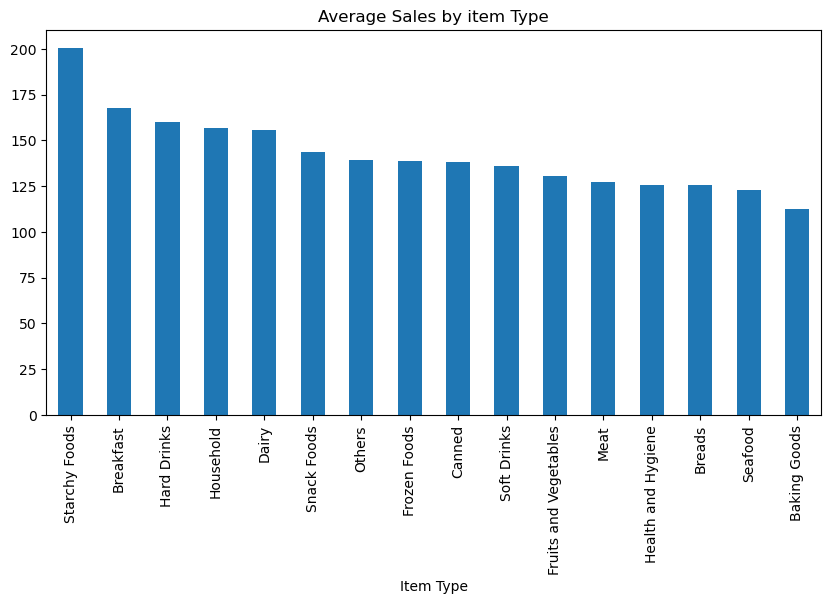

In [8]:
avg_sales_item.plot(kind='bar', figsize=(10,5) , title = 'Average Sales by item Type')

# Understand Performed by Outlet size

In [9]:
sales_by_size = data.groupby('Outlet Size')['Sales'].sum()
sales_by_size

Outlet Size
High       6264.5386
Medium    13457.2128
Small     15055.6272
Name: Sales, dtype: float64

<Axes: title={'center': 'Sales Contribution by Outlet Size'}, ylabel='Sales'>

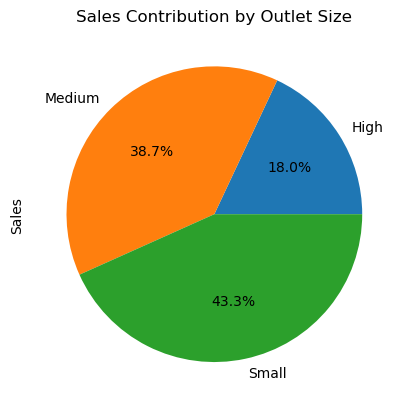

In [11]:
sales_by_size.plot(kind='pie' , autopct='%1.1f%%' , title = 'Sales Contribution by Outlet Size')

# Customer preference based on fat content

In [12]:
fat_sales= data.groupby('Item Fat Content')['Sales'].mean()
fat_sales

Item Fat Content
LF         140.883150
Low Fat    147.527972
Regular    129.048142
low fat     62.102300
reg        111.835600
Name: Sales, dtype: float64

<Axes: title={'center': 'Average Sales by Fat Content'}, xlabel='Item Fat Content'>

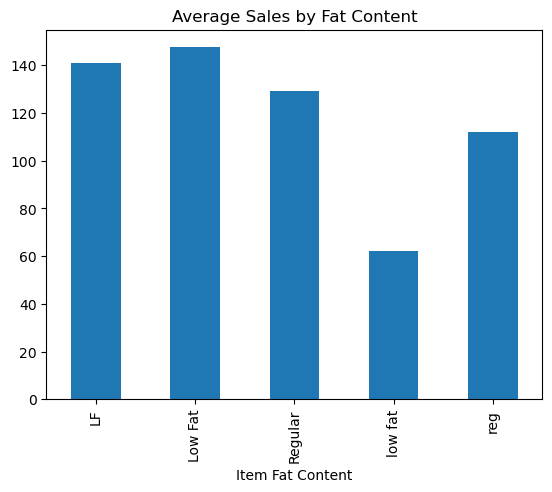

In [14]:
fat_sales.plot(kind='bar' , title='Average Sales by Fat Content')

# Check correlation between visibility and sales.

In [16]:
data[['Item Visibility', 'Sales']].corr()

,Item Visibility,Sales
Item Visibility,1.000000,-0.099294
Sales,-0.099294,1.000000


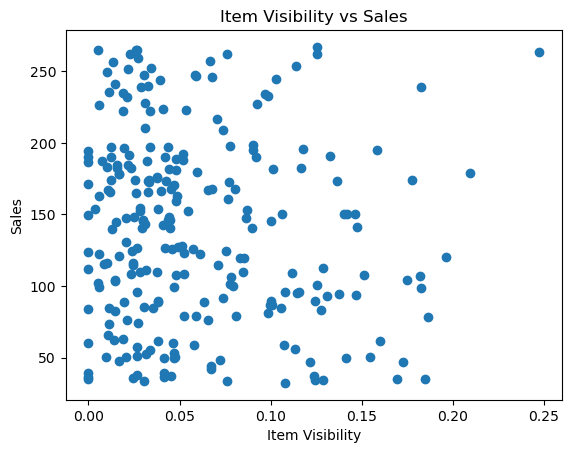

In [17]:
plt.scatter(data['Item Visibility'],data['Sales'])
plt.xlabel('Item Visibility')
plt.ylabel('Sales')
plt.title('Item Visibility vs Sales')
plt.show()

# Tier-based location performance.

In [18]:
location_sales = data.groupby('Outlet Location Type')['Sales'].mean()
location_sales

Outlet Location Type
Tier 1    140.689370
Tier 2    141.006421
Tier 3    123.457744
Name: Sales, dtype: float64

<Axes: title={'center': 'Average Sales by Outlet Location Type'}, xlabel='Outlet Location Type'>

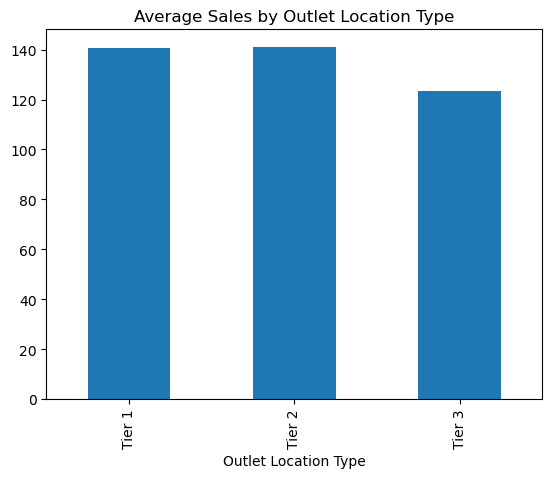

In [19]:
location_sales.plot(kind='bar' , title='Average Sales by Outlet Location Type')

# Older vs Newer outlets performance.

In [20]:
year_sales = data.groupby('Outlet Establishment Year')['Sales'].mean()
year_sales

Outlet Establishment Year
2011    116.015000
2012    144.291861
2014    126.024800
2015    147.587540
2016    129.650925
2017    162.915733
2018    138.263819
2020    132.927267
2022    155.813867
Name: Sales, dtype: float64

<Axes: title={'center': 'Average Sales by Establishment Year'}, xlabel='Outlet Establishment Year'>

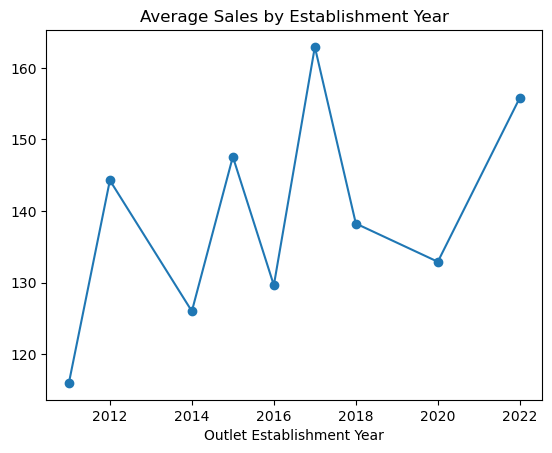

In [21]:
year_sales.plot(kind='line' , marker ='o' , title= 'Average Sales by Establishment Year')

# Customer Satisfaction analysis

In [23]:
rating_item = data.groupby('Item Type')['Rating'].mean().sort_values(ascending=False)
rating_item

Item Type
Baking Goods             5.0
Breads                   5.0
Breakfast                5.0
Canned                   5.0
Dairy                    5.0
Frozen Foods             5.0
Fruits and Vegetables    5.0
Hard Drinks              5.0
Health and Hygiene       5.0
Household                5.0
Meat                     5.0
Others                   5.0
Seafood                  5.0
Snack Foods              5.0
Soft Drinks              5.0
Starchy Foods            5.0
Name: Rating, dtype: float64

<Axes: title={'center': 'Average Rating by Item Type'}, ylabel='Item Type'>

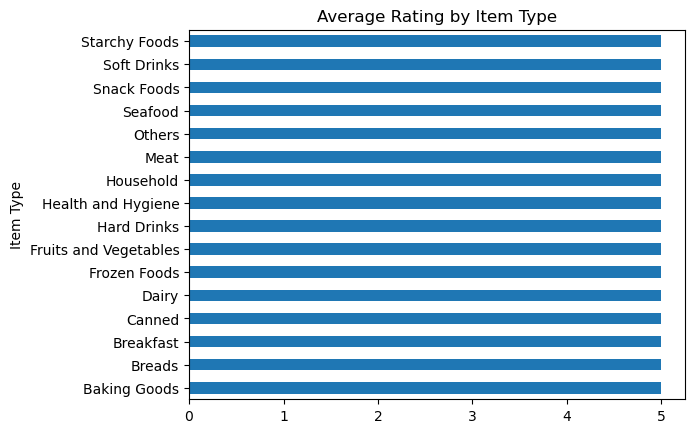

In [25]:
rating_item.plot (kind='barh' , title='Average Rating by Item Type')

# Relation between Item Weight and Sales

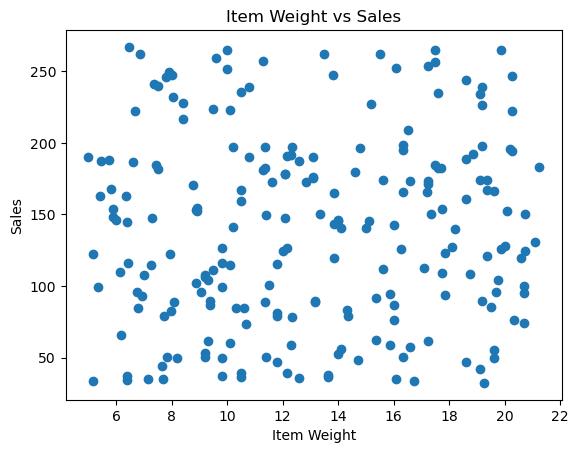

In [27]:
plt.scatter(data['Item Weight'],data['Sales'])
plt.xlabel('Item Weight')
plt.ylabel('Sales')
plt.title('Item Weight vs Sales')
plt.show()

# Finding  top 5 besrt-selling Item Types 

In [28]:
top_items = data.groupby('Item Type')['Sales'].sum().sort_values(ascending=False).head(5)
top_items

Item Type
Household                5009.4844
Fruits and Vegetables    4559.3564
Frozen Foods             4160.5946
Snack Foods              4014.5766
Canned                   2901.5642
Name: Sales, dtype: float64

<Axes: title={'center': 'Top 5 Best Selling Item Types'}, xlabel='Item Type'>

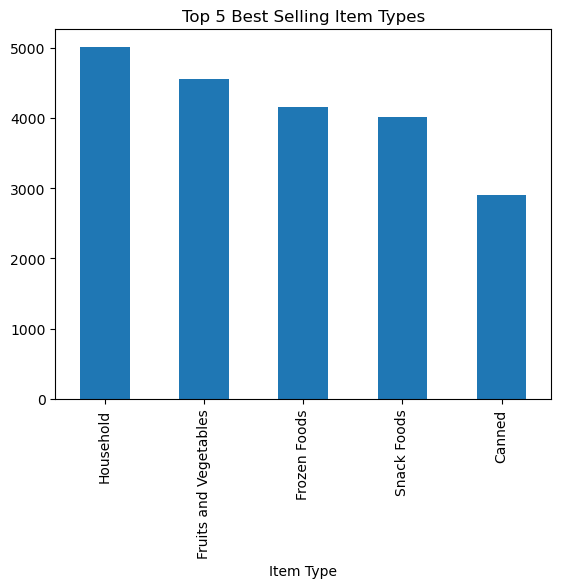

In [29]:
top_items.plot(kind='bar' , title='Top 5 Best Selling Item Types')

# Finding Count of items by Outlet Type.

In [30]:
data['Outlet Type'].value_counts()

Outlet Type
Supermarket Type1    211
Grocery Store         25
Supermarket Type3      8
Supermarket Type2      6
Name: count, dtype: int64

<Axes: title={'center': 'Item Count by Outlet Type'}, xlabel='Outlet Type'>

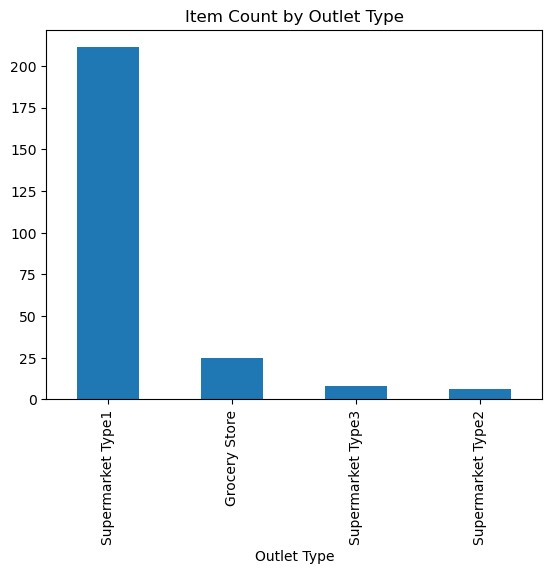

In [31]:
data['Outlet Type'].value_counts().plot(kind='bar' , title= 'Item Count by Outlet Type')